In [191]:
from enums.ScalingMethod import ScalingMethod
from enums.ResamplingMethod import ResamplingMethod
from model.LogisticRegressionModel import LogisticRegressionModel
from model.XGBoostModel import XGBoostModel
from service.datasetservice.DatasetService import DatasetService
from model.ShallowNNModel import ShallowNNModel
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
dataset_service = DatasetService()
database = "test"

# Shallow NN

In [65]:
with_features = True
scaling_method = None
resampling_method = ResamplingMethod.SMOTEENN

In [68]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [69]:
 # 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

None SMOTEENN(random_state=42)


In [70]:
model = ShallowNNModel(scaler=scaler, resampler=resampler, input_shape=x_train.shape[1])
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
Epoch 1/150
2130/2130 - 8s - 4ms/step - accuracy: 0.6143 - loss: 0.6637 - val_accuracy: 0.1003 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 2/150
2129/2129 - 9s - 4ms/step - accuracy: 0.6112 - loss: 0.6608 - val_accuracy: 0.3992 - val_loss: 0.7559 - learning_rate: 0.0010
Epoch 2/150
2129/2129 - 10s - 5ms/step - accuracy: 0.6084 - loss: 0.6610 - val_accuracy: 0.0613 - val_loss: 0.9255 - learning_rate: 0.0010
Epoch 2/150
2130/2130 - 10s - 5ms/step - accuracy: 0.6117 - loss: 0.6603 - val_accuracy: 0.1268 - val_loss: 1.0491 - learning_rate: 0.0010
Epoch 2/150
2130/2130 - 9s - 4ms/step - accuracy: 0.6314 - loss: 0.6241 - val_accuracy: 0.2774 - val_loss: 0.9808 - learning_rate: 0.0010
Epoch 3/150
2130/2130 - 10s - 5ms/step - accuracy: 0.6124 - loss: 0.6623 - val_accuracy: 0.0245 - val_loss: 0.9512 - learning_rate: 0.0010
Epoch 2/150
2129/2129 - 9s - 4ms/step - accuracy: 0.6268 - los

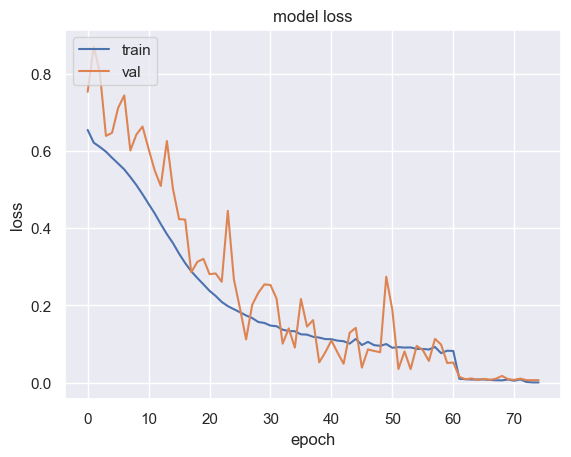

In [72]:
history = model.get_fitted_model().named_steps["clf"].history_

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [73]:
pred_test = model.predict(x=x_test)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

2462/2462 - 1s - 555us/step
616/616 - 0s - 615us/step
{'accuracy': 0.9940086316323941, 'recall': 0.9897843359818388, 'precision': 0.9910699788926773, 'f1': 0.990426740223917, 'confusion_matrix': {'tp': 6104, 'tn': 13473, 'fp': 63, 'fn': 55}}


# Logistic Regression

In [162]:
with_features = True
scaling_method = ScalingMethod.STANDARDSCALER
resampling_method = ResamplingMethod.OVERSAMPLING

In [163]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [164]:
# 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

StandardScaler() RandomOverSampler(random_state=42)


In [165]:
model = LogisticRegressionModel(scaler=scaler, resampler=resampler)
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [167]:
pred_test = model.predict(x=x_test)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

{'accuracy': 0.6161970043158161, 'recall': 0.427159209157128, 'precision': 0.6665043026465335, 'f1': 0.520641765489251, 'confusion_matrix': {'tp': 4105, 'tn': 8031, 'fp': 5505, 'fn': 2054}}


# XGBoost

In [178]:
with_features = True
scaling_method = None
resampling_method = None

In [179]:
x_all, y_all = dataset_service.get_subject_data(subject="all", with_features=with_features)
x_train, x_test, y_train, y_test = dataset_service.train_test_split(x=x_all, y=y_all)

In [180]:
# 1. Initialize model, scaler and resampler
scaler = dataset_service.get_scaler(method=scaling_method)
resampler = dataset_service.get_resampler(method=resampling_method)

print(scaler, resampler)

None None


In [181]:
model = XGBoostModel(scaler=scaler, resampler=resampler)
model.fit(x_train=x_train, y_train=y_train, run_info=dict())

Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [182]:
pred_test = model.predict(x=x_test)
scores_test, _ = model.evaluate(pred=pred_test, y_true=y_test)
print(scores_test)

{'accuracy': 0.9992383853769993, 'recall': 0.9993498049414824, 'precision': 0.9982139957785354, 'f1': 0.99878157745106, 'confusion_matrix': {'tp': 6148, 'tn': 13532, 'fp': 4, 'fn': 11}}
